In [1]:
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Subset
from torchvision import datasets, transforms

from sklearn.model_selection import train_test_split, KFold
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, mean_squared_error, mean_absolute_error

# Set fixed seed for full reproducibility
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1. Load Dataset
transform = transforms.Compose([transforms.ToTensor()])
train_dataset_raw = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset_raw = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Flatten and extract numpy arrays
X_full = train_dataset_raw.data.numpy().reshape(-1, 784).astype(np.float32) / 255.0
y_full = train_dataset_raw.targets.numpy()

X_test = test_dataset_raw.data.numpy().reshape(-1, 784).astype(np.float32) / 255.0
y_test = test_dataset_raw.targets.numpy()

# 2. Stratified 80/20 Train/Validation Split
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=0.2, random_state=SEED, stratify=y_full
)

# 3. Report split sizes and class distribution
print(f"Train samples: {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

train_dist = pd.Series(y_train).value_counts().sort_index()
val_dist = pd.Series(y_val).value_counts().sort_index()
print("\nTrain Class Distribution:\n", train_dist)
print("\nVal Class Distribution:\n", val_dist)

Using device: cuda


100%|██████████| 26.4M/26.4M [00:01<00:00, 13.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.77MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.0MB/s]


Train samples: 48000
Validation samples: 12000
Test samples: 10000

Train Class Distribution:
 0    4800
1    4800
2    4800
3    4800
4    4800
5    4800
6    4800
7    4800
8    4800
9    4800
Name: count, dtype: int64

Val Class Distribution:
 0    1200
1    1200
2    1200
3    1200
4    1200
5    1200
6    1200
7    1200
8    1200
9    1200
Name: count, dtype: int64


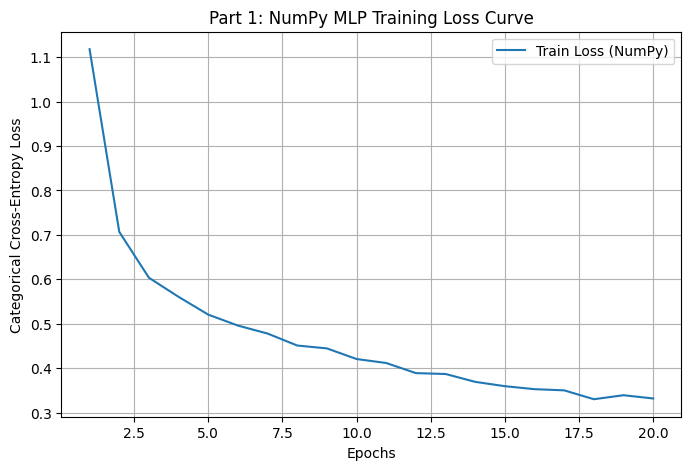

Max Gradient Difference W1: 2.10568062e-08
Max Gradient Difference b1: 2.17845827e-08
Max Gradient Difference W2: 8.33688425e-08
Max Gradient Difference b2: 2.60003289e-08


In [2]:
# --- NumPy 2-Layer MLP Implementation ---
class TwoLayerMLPNumPy:
    def __init__(self, input_dim=784, hidden_dim=64, output_dim=10):
        set_seed(SEED)
        # He / Xavier initialization
        self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2.0 / input_dim)
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = np.random.randn(hidden_dim, output_dim) * np.sqrt(2.0 / hidden_dim)
        self.b2 = np.zeros((1, output_dim))

    def relu(self, Z):
        return np.maximum(0, Z)

    def softmax(self, Z):
        exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

    def forward(self, X):
        self.X = X
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self.relu(self.Z1)
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = self.softmax(self.Z2)
        return self.A2

    def compute_loss(self, Y_onehot):
        m = Y_onehot.shape[0]
        loss = -np.sum(Y_onehot * np.log(self.A2 + 1e-15)) / m
        return loss

    def backward(self, Y_onehot):
        m = Y_onehot.shape[0]

        # Output layer gradients
        dZ2 = (self.A2 - Y_onehot) / m
        self.dW2 = np.dot(self.A1.T, dZ2)
        self.db2 = np.sum(dZ2, axis=0, keepdims=True)

        # Hidden layer gradients
        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = dA1 * (self.Z1 > 0)
        self.dW1 = np.dot(self.X.T, dZ1)
        self.db1 = np.sum(dZ1, axis=0, keepdims=True)

    def step(self, lr):
        self.W1 -= lr * self.dW1
        self.b1 -= lr * self.db1
        self.W2 -= lr * self.dW2
        self.b2 -= lr * self.db2

# Train on 5,000 subset for 20 epochs
X_sub = X_train[:5000]
y_sub = y_train[:5000]
Y_sub_onehot = np.eye(10)[y_sub]

numpy_model = TwoLayerMLPNumPy()
losses = []
epochs = 20
batch_size = 64
lr = 0.1

for epoch in range(epochs):
    permutation = np.random.permutation(5000)
    epoch_loss = 0
    batches = 0
    for i in range(0, 5000, batch_size):
        idx = permutation[i:i+batch_size]
        X_b, Y_b = X_sub[idx], Y_sub_onehot[idx]

        preds = numpy_model.forward(X_b)
        loss = numpy_model.compute_loss(Y_b)
        numpy_model.backward(Y_b)
        numpy_model.step(lr)

        epoch_loss += loss
        batches += 1
    losses.append(epoch_loss / batches)

plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), losses, label='Train Loss (NumPy)')
plt.xlabel('Epochs')
plt.ylabel('Categorical Cross-Entropy Loss')
plt.title('Part 1: NumPy MLP Training Loss Curve')
plt.legend()
plt.grid(True)
plt.show()

# --- Gradient Verification against PyTorch ---
torch_model = nn.Sequential(
    nn.Linear(784, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

# Copy parameters from initialized NumPy model
with torch.no_grad():
    torch_model[0].weight.copy_(torch.tensor(numpy_model.W1.T, dtype=torch.float32))
    torch_model[0].bias.copy_(torch.tensor(numpy_model.b1.squeeze(), dtype=torch.float32))
    torch_model[2].weight.copy_(torch.tensor(numpy_model.W2.T, dtype=torch.float32))
    torch_model[2].bias.copy_(torch.tensor(numpy_model.b2.squeeze(), dtype=torch.float32))

# Run forward + backward pass on a single batch
X_sample = torch.tensor(X_sub[:64], dtype=torch.float32)
Y_sample = torch.tensor(y_sub[:64], dtype=torch.long)

numpy_model.forward(X_sub[:64])
numpy_model.backward(Y_sub_onehot[:64])

criterion = nn.CrossEntropyLoss()
out = torch_model(X_sample)
loss_torch = criterion(out, Y_sample)
torch_model.zero_grad()
loss_torch.backward()

# Calculate Max Absolute Difference
diff_W1 = np.max(np.abs(numpy_model.dW1 - torch_model[0].weight.grad.numpy().T))
diff_b1 = np.max(np.abs(numpy_model.db1.squeeze() - torch_model[0].bias.grad.numpy()))
diff_W2 = np.max(np.abs(numpy_model.dW2 - torch_model[2].weight.grad.numpy().T))
diff_b2 = np.max(np.abs(numpy_model.db2.squeeze() - torch_model[2].bias.grad.numpy()))

print(f"Max Gradient Difference W1: {diff_W1:.8e}")
print(f"Max Gradient Difference b1: {diff_b1:.8e}")
print(f"Max Gradient Difference W2: {diff_W2:.8e}")
print(f"Max Gradient Difference b2: {diff_b2:.8e}")

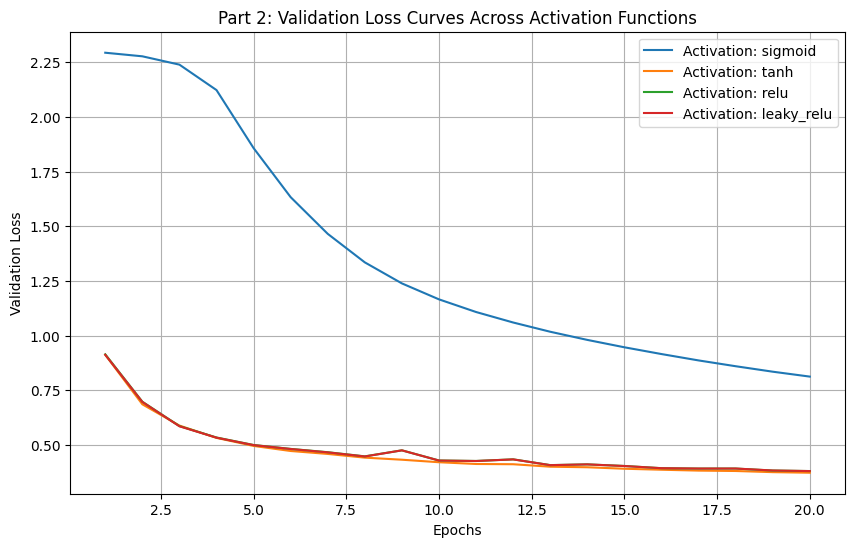

Mean Absolute Gradients (First Hidden Layer):
Sigmoid -> Epoch 1: 0.000103, Epoch 20: 0.000432
ReLU    -> Epoch 1: 0.001051, Epoch 20: 0.003303
Dead ReLU percentage in 1st hidden layer: 0.00%


In [3]:
class FlexibleMLP(nn.Module):
    def __init__(self, activation_name):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

        activations = {
            'sigmoid': nn.Sigmoid(),
            'tanh': nn.Tanh(),
            'relu': nn.ReLU(),
            'leaky_relu': nn.LeakyReLU(0.01)
        }
        self.act = activations[activation_name]

    def forward(self, x):
        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        return self.fc3(x)

def train_and_eval_activations(X_tr, y_tr, X_v, y_v, epochs=20, batch_size=64, lr=0.01):
    train_ds = TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr, dtype=torch.long))
    val_ds = TensorDataset(torch.tensor(X_v), torch.tensor(y_v, dtype=torch.long))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    activations = ['sigmoid', 'tanh', 'relu', 'leaky_relu']
    val_losses = {}
    layer1_grads = {}

    for act in activations:
        set_seed()
        model = FlexibleMLP(act).to(device)
        optimizer = optim.SGD(model.parameters(), lr=lr)
        criterion = nn.CrossEntropyLoss()

        act_val_losses = []
        epoch1_grad, final_grad = 0.0, 0.0

        for epoch in range(epochs):
            model.train()
            grad_sum = 0.0
            for bx, by in train_loader:
                bx, by = bx.to(device), by.to(device)
                optimizer.zero_grad()
                out = model(bx)
                loss = criterion(out, by)
                loss.backward()

                grad_sum += model.fc1.weight.grad.abs().mean().item()
                optimizer.step()

            if epoch == 0:
                epoch1_grad = grad_sum / len(train_loader)
            if epoch == epochs - 1:
                final_grad = grad_sum / len(train_loader)

            # Validation loss calculation
            model.eval()
            v_loss = 0.0
            with torch.no_grad():
                for bx, by in val_loader:
                    bx, by = bx.to(device), by.to(device)
                    v_loss += criterion(model(bx), by).item()
            act_val_losses.append(v_loss / len(val_loader))

        val_losses[act] = act_val_losses
        layer1_grads[act] = (epoch1_grad, final_grad)

    return val_losses, layer1_grads

val_losses, layer1_grads = train_and_eval_activations(X_train, y_train, X_val, y_val)

# Plot activation comparison
plt.figure(figsize=(10, 6))
for act, losses in val_losses.items():
    plt.plot(range(1, 21), losses, label=f'Activation: {act}')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.title('Part 2: Validation Loss Curves Across Activation Functions')
plt.legend()
plt.grid(True)
plt.show()

# Report First Hidden Layer Mean Absolute Gradients
print("Mean Absolute Gradients (First Hidden Layer):")
print(f"Sigmoid -> Epoch 1: {layer1_grads['sigmoid'][0]:.6f}, Epoch 20: {layer1_grads['sigmoid'][1]:.6f}")
print(f"ReLU    -> Epoch 1: {layer1_grads['relu'][0]:.6f}, Epoch 20: {layer1_grads['relu'][1]:.6f}")

# Compute Dead ReLU Ratio
set_seed()
relu_model = FlexibleMLP('relu').to(device)
val_sample = torch.tensor(X_val[:1000]).to(device)
with torch.no_grad():
    fc1_out = F.relu(relu_model.fc1(val_sample))
    dead_units = (fc1_out.sum(dim=0) == 0).sum().item()
    dead_percentage = (dead_units / fc1_out.shape[1]) * 100

print(f"Dead ReLU percentage in 1st hidden layer: {dead_percentage:.2f}%")

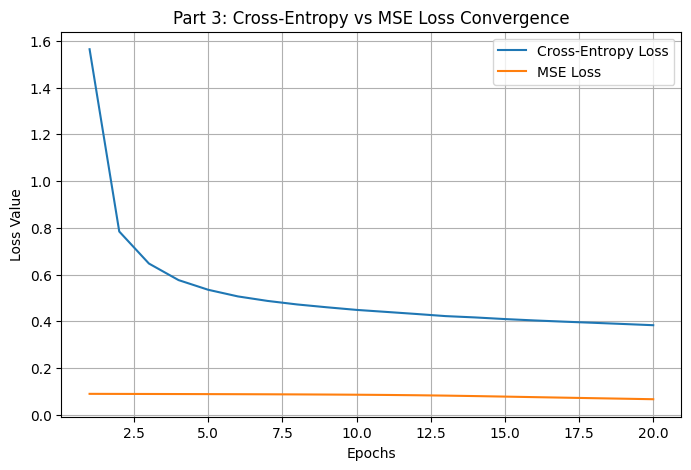

Regression Test Performance -> MSE: 0.2990, RMSE: 0.5468, MAE: 0.3754


In [4]:
# 1. Categorical Cross-Entropy vs Mean Squared Error for Classification
def run_loss_comparison():
    train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train, dtype=torch.long))
    test_ds = TensorDataset(torch.tensor(X_test), torch.tensor(y_test, dtype=torch.long))
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

    # Cross-Entropy Training
    set_seed()
    model_ce = FlexibleMLP('relu').to(device)
    opt_ce = optim.SGD(model_ce.parameters(), lr=0.01)
    ce_loss_fn = nn.CrossEntropyLoss()
    ce_train_losses = []

    for epoch in range(20):
        m_loss = 0.0
        model_ce.train()
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            opt_ce.zero_grad()
            out = model_ce(bx)
            loss = ce_loss_fn(out, by)
            loss.backward()
            opt_ce.step()
            m_loss += loss.item()
        ce_train_losses.append(m_loss / len(train_loader))

    # MSE Training
    set_seed()
    model_mse = FlexibleMLP('relu').to(device)
    opt_mse = optim.SGD(model_mse.parameters(), lr=0.01)
    mse_loss_fn = nn.MSELoss()
    mse_train_losses = []

    for epoch in range(20):
        m_loss = 0.0
        model_mse.train()
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            by_onehot = F.one_hot(by, num_classes=10).float()
            opt_mse.zero_grad()
            out = F.softmax(model_mse(bx), dim=1)
            loss = mse_loss_fn(out, by_onehot)
            loss.backward()
            opt_mse.step()
            m_loss += loss.item()
        mse_train_losses.append(m_loss / len(train_loader))

    plt.figure(figsize=(8, 5))
    plt.plot(range(1, 21), ce_train_losses, label='Cross-Entropy Loss')
    plt.plot(range(1, 21), mse_train_losses, label='MSE Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss Value')
    plt.title('Part 3: Cross-Entropy vs MSE Loss Convergence')
    plt.legend()
    plt.grid(True)
    plt.show()

run_loss_comparison()

# 2. Tabular Regression Evaluation (California Housing Dataset)
california = fetch_california_housing()
X_reg, y_reg = california.data, california.target
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=SEED)

scaler = StandardScaler()
X_tr_r = scaler.fit_transform(X_tr_r)
X_te_r = scaler.transform(X_te_r)

class RegressorMLP(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.net(x)

reg_model = RegressorMLP(X_tr_r.shape[1]).to(device)
reg_opt = optim.Adam(reg_model.parameters(), lr=0.001)
reg_criterion = nn.MSELoss()

reg_ds = TensorDataset(torch.tensor(X_tr_r, dtype=torch.float32), torch.tensor(y_tr_r, dtype=torch.float32).unsqueeze(1))
reg_loader = DataLoader(reg_ds, batch_size=32, shuffle=True)

for epoch in range(30):
    reg_model.train()
    for bx, by in reg_loader:
        bx, by = bx.to(device), by.to(device)
        reg_opt.zero_grad()
        loss = reg_criterion(reg_model(bx), by)
        loss.backward()
        reg_opt.step()

reg_model.eval()
with torch.no_grad():
    preds = reg_model(torch.tensor(X_te_r, dtype=torch.float32).to(device)).cpu().numpy()

mse_val = mean_squared_error(y_te_r, preds)
rmse_val = np.sqrt(mse_val)
mae_val = mean_absolute_error(y_te_r, preds)

print(f"Regression Test Performance -> MSE: {mse_val:.4f}, RMSE: {rmse_val:.4f}, MAE: {mae_val:.4f}")

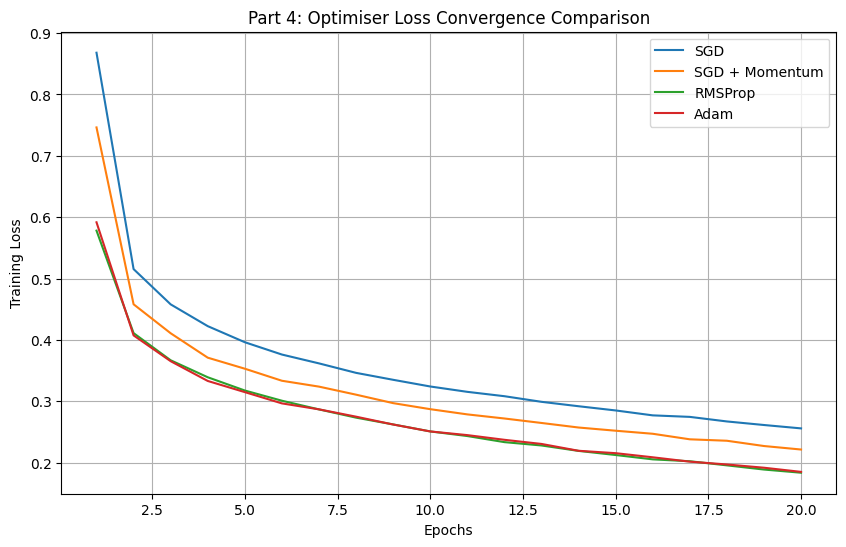

     Optimiser  Learning rate  Epochs to reach 85% validation accuracy Final validation accuracy Wall-clock time (s)
           SGD          0.050                                        3                    0.8877               31.20
SGD + Momentum          0.010                                        2                    0.8902               32.39
       RMSProp          0.001                                        1                    0.8938               37.66
          Adam          0.001                                        2                    0.8962               35.85


In [6]:
def evaluate_optimizers():
    optimizers_config = {
        'SGD': lambda params, lr: optim.SGD(params, lr=lr),
        'SGD + Momentum': lambda params, lr: optim.SGD(params, lr=lr, momentum=0.9),
        'RMSProp': lambda params, lr: optim.RMSprop(params, lr=lr),
        'Adam': lambda params, lr: optim.Adam(params, lr=lr)
    }

    tuned_lrs = {'SGD': 0.05, 'SGD + Momentum': 0.01, 'RMSProp': 0.001, 'Adam': 0.001}
    results = []

    train_ds = TensorDataset(torch.tensor(X_train), torch.tensor(y_train, dtype=torch.long))
    val_ds = TensorDataset(torch.tensor(X_val), torch.tensor(y_val, dtype=torch.long))
    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

    plt.figure(figsize=(10, 6))

    for name, opt_builder in optimizers_config.items():
        set_seed()
        model = FlexibleMLP('relu').to(device)
        lr = tuned_lrs[name]
        optimizer = opt_builder(model.parameters(), lr)
        criterion = nn.CrossEntropyLoss()

        epochs_to_85 = "N/A"
        final_val_acc = 0.0
        train_losses = []

        start_time = time.time()
        for epoch in range(20):
            model.train()
            e_loss = 0.0
            for bx, by in train_loader:
                bx, by = bx.to(device), by.to(device)
                optimizer.zero_grad()
                out = model(bx)
                loss = criterion(out, by)
                loss.backward()
                optimizer.step()
                e_loss += loss.item()

            train_losses.append(e_loss / len(train_loader))

            # Validation Step
            model.eval()
            correct, total = 0, 0
            with torch.no_grad():
                for bx, by in val_loader:
                    bx, by = bx.to(device), by.to(device)
                    preds = model(bx).argmax(dim=1)
                    correct += (preds == by).sum().item()
                    total += by.size(0)

            val_acc = correct / total
            if val_acc >= 0.85 and epochs_to_85 == "N/A":
                epochs_to_85 = epoch + 1
            final_val_acc = val_acc

        wall_time = time.time() - start_time
        plt.plot(range(1, 21), train_losses, label=f'{name}')

        results.append({
            'Optimiser': name,
            'Learning rate': lr,
            'Epochs to reach 85% validation accuracy': epochs_to_85,
            'Final validation accuracy': f"{final_val_acc:.4f}",
            'Wall-clock time (s)': f"{wall_time:.2f}"
        })

    plt.xlabel('Epochs')
    plt.ylabel('Training Loss')
    plt.title('Part 4: Optimiser Loss Convergence Comparison')
    plt.legend()
    plt.grid(True)
    plt.show()

    df_opt = pd.DataFrame(results)
    print(df_opt.to_string(index=False))

evaluate_optimizers()

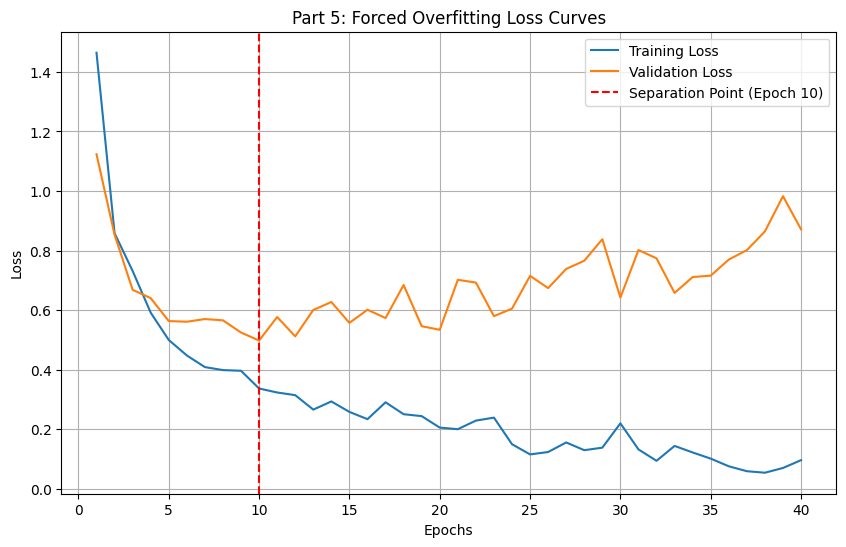

Final Train Accuracy: 0.9660
Final Validation Accuracy: 0.8207
Generalisation Gap: 0.1453


In [7]:
class OverfittedMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )
    def forward(self, x):
        return self.net(x)

# Reduced Dataset (2,000 samples)
X_overfit, y_overfit = X_train[:2000], y_train[:2000]

train_ds_of = TensorDataset(torch.tensor(X_overfit), torch.tensor(y_overfit, dtype=torch.long))
val_ds_of = TensorDataset(torch.tensor(X_val), torch.tensor(y_val, dtype=torch.long))

train_loader_of = DataLoader(train_ds_of, batch_size=64, shuffle=True)
val_loader_of = DataLoader(val_ds_of, batch_size=64, shuffle=False)

set_seed()
model_of = OverfittedMLP().to(device)
optimizer_of = optim.Adam(model_of.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

train_losses, val_losses = [], []
train_accs, val_accs = [], []

epochs = 40
for epoch in range(epochs):
    model_of.train()
    t_loss, t_correct, t_total = 0.0, 0, 0
    for bx, by in train_loader_of:
        bx, by = bx.to(device), by.to(device)
        optimizer_of.zero_grad()
        out = model_of(bx)
        loss = criterion(out, by)
        loss.backward()
        optimizer_of.step()

        t_loss += loss.item()
        t_correct += (out.argmax(dim=1) == by).sum().item()
        t_total += by.size(0)

    train_losses.append(t_loss / len(train_loader_of))
    train_accs.append(t_correct / t_total)

    model_of.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():
        for bx, by in val_loader_of:
            bx, by = bx.to(device), by.to(device)
            out = model_of(bx)
            v_loss += criterion(out, by).item()
            v_correct += (out.argmax(dim=1) == by).sum().item()
            v_total += by.size(0)

    val_losses.append(v_loss / len(val_loader_of))
    val_accs.append(v_correct / v_total)

# Plot Loss Curve & Mark Separation Epoch
plt.figure(figsize=(10, 6))
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')

# Calculate Separation Epoch
sep_epoch = np.argmin(val_losses) + 1
plt.axvline(x=sep_epoch, color='r', linestyle='--', label=f'Separation Point (Epoch {sep_epoch})')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Part 5: Forced Overfitting Loss Curves')
plt.legend()
plt.grid(True)
plt.show()

gen_gap = train_accs[-1] - val_accs[-1]
print(f"Final Train Accuracy: {train_accs[-1]:.4f}")
print(f"Final Validation Accuracy: {val_accs[-1]:.4f}")
print(f"Generalisation Gap: {gen_gap:.4f}")

                      Method Setting Train accuracy Validation accuracy    Gap
Baseline (no regularisation) Default         0.9565              0.8207 0.1358
             L2 weight decay   0.001         0.9565              0.8218 0.1347
                  L1 penalty  0.0001         0.9475              0.8205 0.1270
                     Dropout     0.4         0.9185              0.8217 0.0968
         Batch normalisation Default         0.9660              0.8054 0.1606
              Early stopping Default         0.9245              0.8198 0.1047
           Data augmentation Default         0.8975              0.8236 0.0739
    More training data (10k)   10000         0.9482              0.8574 0.0908
    More training data (20k)   20000         0.9670              0.8899 0.0771


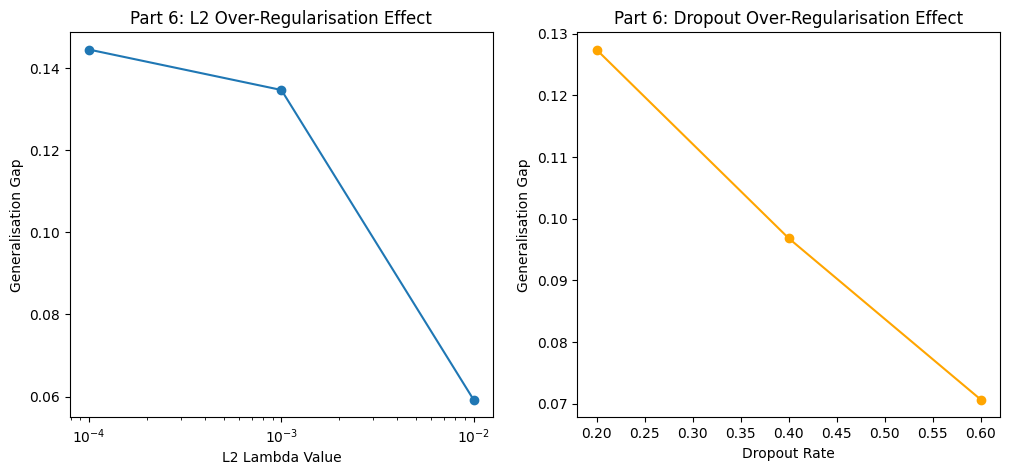

In [8]:
class RegularizedMLP(nn.Module):
    def __init__(self, use_bn=False, dropout_rate=0.0):
        super().__init__()
        layers = []
        dims = [784, 512, 512, 512, 512, 10]

        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            if i < len(dims) - 2:
                if use_bn:
                    layers.append(nn.BatchNorm1d(dims[i+1]))
                layers.append(nn.ReLU())
                if dropout_rate > 0.0:
                    layers.append(nn.Dropout(dropout_rate))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def run_regularization_experiment(reg_type, setting_val, X_tr=X_overfit, y_tr=y_overfit):
    set_seed()

    use_bn = (reg_type == 'batch_norm')
    dropout_rate = setting_val if reg_type == 'dropout' else 0.0
    model = RegularizedMLP(use_bn=use_bn, dropout_rate=dropout_rate).to(device)

    weight_decay = setting_val if reg_type == 'l2' else 0.0
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    # Data Augmentation Setup
    if reg_type == 'data_aug':
        transform_aug = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15)
        ])

    train_ds = TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr, dtype=torch.long))
    val_ds = TensorDataset(torch.tensor(X_val), torch.tensor(y_val, dtype=torch.long))

    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

    best_val_loss = float('inf')
    patience = 5
    patience_counter = 0
    stopped_epoch = 40

    for epoch in range(40):
        model.train()
        for bx, by in train_loader:
            if reg_type == 'data_aug':
                bx_reshaped = bx.view(-1, 1, 28, 28)
                bx = transform_aug(bx_reshaped).view(-1, 784)

            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            out = model(bx)

            loss = criterion(out, by)
            if reg_type == 'l1':
                l1_norm = sum(p.abs().sum() for p in model.parameters())
                loss += setting_val * l1_norm

            loss.backward()
            optimizer.step()

        # Validation Step
        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for bx, by in val_loader:
                bx, by = bx.to(device), by.to(device)
                v_loss += criterion(model(bx), by).item()

        v_loss /= len(val_loader)

        if reg_type == 'early_stopping':
            if v_loss < best_val_loss:
                best_val_loss = v_loss
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    stopped_epoch = epoch + 1
                    break

    # Calculate final Train and Val accuracy
    model.eval()
    def get_acc(loader):
        correct, total = 0, 0
        with torch.no_grad():
            for bx, by in loader:
                bx, by = bx.to(device), by.to(device)
                correct += (model(bx).argmax(dim=1) == by).sum().item()
                total += by.size(0)
        return correct / total

    train_acc = get_acc(train_loader)
    val_acc = get_acc(val_loader)
    gap = train_acc - val_acc

    extra_info = None
    if reg_type == 'l1':
        all_weights = torch.cat([p.view(-1) for p in model.parameters()])
        sparsity = (all_weights.abs() < 1e-3).float().mean().item() * 100
        extra_info = f"Sparsity: {sparsity:.1f}%"
    elif reg_type == 'early_stopping':
        extra_info = f"Stopped Epoch: {stopped_epoch}"

    return train_acc, val_acc, gap, extra_info

# Construct Summary Table
reg_experiments = [
    ('Baseline (no regularisation)', 'none', None),
    ('L2 weight decay', 'l2', 1e-3),
    ('L1 penalty', 'l1', 1e-4),
    ('Dropout', 'dropout', 0.4),
    ('Batch normalisation', 'batch_norm', None),
    ('Early stopping', 'early_stopping', None),
    ('Data augmentation', 'data_aug', None),
    ('More training data (10k)', 'more_data', 10000),
    ('More training data (20k)', 'more_data', 20000),
]

reg_results = []
for name, r_type, setting in reg_experiments:
    if r_type == 'more_data':
        tr_acc, v_acc, gap, info = run_regularization_experiment('none', None, X_train[:setting], y_train[:setting])
    else:
        tr_acc, v_acc, gap, info = run_regularization_experiment(r_type, setting)

    reg_results.append({
        'Method': name,
        'Setting': str(setting) if setting else 'Default',
        'Train accuracy': f"{tr_acc:.4f}",
        'Validation accuracy': f"{v_acc:.4f}",
        'Gap': f"{gap:.4f}"
    })

df_reg = pd.DataFrame(reg_results)
print(df_reg.to_string(index=False))

# Sensitivity Plotting
l2_lambdas = [1e-4, 1e-3, 1e-2]
l2_gaps = [run_regularization_experiment('l2', lam)[2] for lam in l2_lambdas]

dropout_rates = [0.2, 0.4, 0.6]
drop_gaps = [run_regularization_experiment('dropout', dr)[2] for dr in dropout_rates]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(l2_lambdas, l2_gaps, marker='o')
ax[0].set_xscale('log')
ax[0].set_xlabel('L2 Lambda Value')
ax[0].set_ylabel('Generalisation Gap')
ax[0].set_title('Part 6: L2 Over-Regularisation Effect')

ax[1].plot(dropout_rates, drop_gaps, marker='o', color='orange')
ax[1].set_xlabel('Dropout Rate')
ax[1].set_ylabel('Generalisation Gap')
ax[1].set_title('Part 6: Dropout Over-Regularisation Effect')
plt.show()

Top 5 Hyperparameter Configurations (5-Fold CV):
Rank 1: Config={'lr': 0.001, 'width': 128, 'dropout': 0.2} | CV Accuracy=0.8870 +/- 0.0054
Rank 2: Config={'lr': 0.001, 'width': 512, 'dropout': 0.3} | CV Accuracy=0.8857 +/- 0.0026
Rank 3: Config={'lr': 0.0005, 'width': 128, 'dropout': 0.2} | CV Accuracy=0.8850 +/- 0.0036
Rank 4: Config={'lr': 0.005, 'width': 128, 'dropout': 0.2} | CV Accuracy=0.8838 +/- 0.0028
Rank 5: Config={'lr': 0.001, 'width': 128, 'dropout': 0.3} | CV Accuracy=0.8826 +/- 0.0032

--- Final Test Set Results ---
Test Accuracy:    89.64%
Macro Precision:  0.8961
Macro Recall:     0.8964
Macro F1-Score:   0.8957


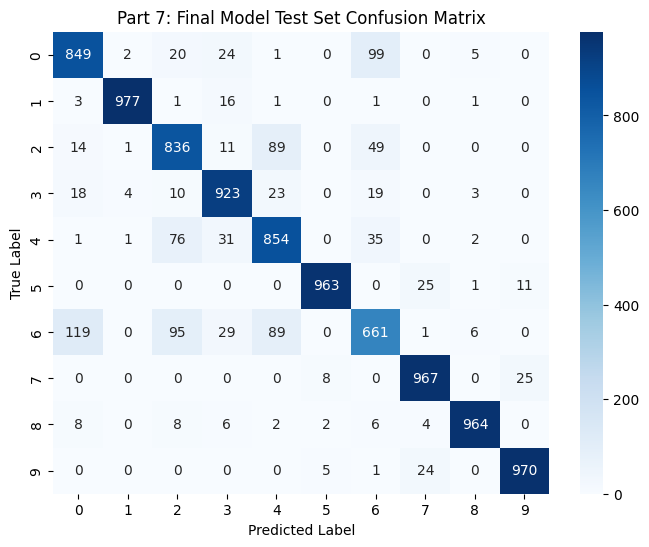

In [9]:
# Random Search Space Configuration
search_space = {
    'lr': [0.0005, 0.001, 0.005, 0.01],
    'width': [128, 256, 512],
    'dropout': [0.2, 0.3, 0.5]
}

def generate_random_configs(num_samples=12):
    set_seed()
    configs = []
    for _ in range(num_samples):
        cfg = {
            'lr': float(np.random.choice(search_space['lr'])),
            'width': int(np.random.choice(search_space['width'])),
            'dropout': float(np.random.choice(search_space['dropout']))
        }
        if cfg not in configs:
            configs.append(cfg)
    return configs

class TunableMLP(nn.Module):
    def __init__(self, width, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, width),
            nn.BatchNorm1d(width),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(width, width),
            nn.BatchNorm1d(width),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(width, 10)
        )
    def forward(self, x):
        return self.net(x)

# 5-Fold Cross Validation Setup
configs = generate_random_configs(12)
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results = []

for idx, cfg in enumerate(configs):
    fold_accs = []
    for train_idx, val_idx in kf.split(X_train):
        X_tr_f, y_tr_f = X_train[train_idx], y_train[train_idx]
        X_va_f, y_va_f = X_train[val_idx], y_train[val_idx]

        train_loader = DataLoader(TensorDataset(torch.tensor(X_tr_f), torch.tensor(y_tr_f, dtype=torch.long)), batch_size=64, shuffle=True)
        val_loader = DataLoader(TensorDataset(torch.tensor(X_va_f), torch.tensor(y_va_f, dtype=torch.long)), batch_size=64, shuffle=False)

        model = TunableMLP(cfg['width'], cfg['dropout']).to(device)
        optimizer = optim.Adam(model.parameters(), lr=cfg['lr'])
        criterion = nn.CrossEntropyLoss()

        for epoch in range(10):
            model.train()
            for bx, by in train_loader:
                bx, by = bx.to(device), by.to(device)
                optimizer.zero_grad()
                loss = criterion(model(bx), by)
                loss.backward()
                optimizer.step()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for bx, by in val_loader:
                bx, by = bx.to(device), by.to(device)
                correct += (model(bx).argmax(dim=1) == by).sum().item()
                total += by.size(0)
        fold_accs.append(correct / total)

    mean_acc = np.mean(fold_accs)
    std_acc = np.std(fold_accs)
    cv_results.append({'cfg': cfg, 'mean': mean_acc, 'std': std_acc})

# Sort and Report Top 5 Configurations
cv_results = sorted(cv_results, key=lambda x: x['mean'], reverse=True)
print("Top 5 Hyperparameter Configurations (5-Fold CV):")
for idx, res in enumerate(cv_results[:5]):
    print(f"Rank {idx+1}: Config={res['cfg']} | CV Accuracy={res['mean']:.4f} +/- {res['std']:.4f}")

# Train Best Configuration on Full Training Set and Evaluate on Held-Out Test Set
best_cfg = cv_results[0]['cfg']

train_full_loader = DataLoader(TensorDataset(torch.tensor(X_full), torch.tensor(y_full, dtype=torch.long)), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test), torch.tensor(y_test, dtype=torch.long)), batch_size=64, shuffle=False)

best_model = TunableMLP(best_cfg['width'], best_cfg['dropout']).to(device)
best_optimizer = optim.Adam(best_model.parameters(), lr=best_cfg['lr'])
criterion = nn.CrossEntropyLoss()

for epoch in range(25):
    best_model.train()
    for bx, by in train_full_loader:
        bx, by = bx.to(device), by.to(device)
        best_optimizer.zero_grad()
        loss = criterion(best_model(bx), by)
        loss.backward()
        best_optimizer.step()

# Single Final Evaluation on Test Set
best_model.eval()
y_true_list, y_pred_list = [], []
with torch.no_grad():
    for bx, by in test_loader:
        bx, by = bx.to(device), by.to(device)
        preds = best_model(bx).argmax(dim=1)
        y_true_list.extend(by.cpu().numpy())
        y_pred_list.extend(preds.cpu().numpy())

test_acc = (np.array(y_true_list) == np.array(y_pred_list)).mean()
macro_prec = precision_score(y_true_list, y_pred_list, average='macro')
macro_rec = recall_score(y_true_list, y_pred_list, average='macro')
macro_f1 = f1_score(y_true_list, y_pred_list, average='macro')

print("\n--- Final Test Set Results ---")
print(f"Test Accuracy:    {test_acc * 100:.2f}%")
print(f"Macro Precision:  {macro_prec:.4f}")
print(f"Macro Recall:     {macro_rec:.4f}")
print(f"Macro F1-Score:   {macro_f1:.4f}")

# Plot Confusion Matrix
cm = confusion_matrix(y_true_list, y_pred_list)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Part 7: Final Model Test Set Confusion Matrix')
plt.show()